In [1]:
import numpy as np
import xarray as xr
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight

The Z-score method is the "gold standard" in climate science because it solves the Context Problem.
- It handles Seasonality: A raw value of $0.2 m^3/m^3$ might be a "flood" during the dry season but a "severe drought" during the rainy season. Z-scores compare January data only to other Januaries, making the "categories" accurate year-round.
- It’s Spatially Fair: It allows you to compare a pixel in the Sahara to a pixel in the Amazon. Since both are scaled to their own local "normal," a $Z = -2.0$ means "historically dry" for both locations, regardless of their actual moisture levels.
- It Predicts "Anomalies": Most stakeholders (farmers, insurers) don't care about the average moisture—they care about the departure from normal. Z-scores isolate that "weirdness," making your model much more useful for risk assessment.

In short: Fixed buckets tell you how much water is there; Z-score buckets tell you if that amount is actually a problem.

The Z-score for each soil moisture value ($x$) will be calculated as follows:

$$Z = \frac{x - \mu}{\sigma}$$

Where $\mu$ is the historical mean and $\sigma$ is the standard deviation for that specific location and month.I chose this method over fixed thresholds or simple quantiles because it effectively handles seasonality and spatial variability. By centering the data around the local "normal," the model can predict meaningful anomalies (e.g., "Severely Dry") regardless of whether the pixel is in a naturally arid or humid region. This approach is also widely supported in hydrological literature, often referred to as the Standardized Soil Moisture Index (SSI).

#### 5 classes

30 day lead time

In [2]:
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear

# Ensure your time column is datetime and extract the month
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
# This helps the model understand that Dec and Jan are neighbors
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Calculate Mean and Std Dev per month (and per pixel/station if applicable)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()

# Merge stats back to original dataframe
df = df.merge(stats, on='month')

# Calculate Z-score
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# Create Buckets
bins = [-float('inf'), -1.5, -0.5, 0.5, 1.5, float('inf')]
labels = ['Severely Dry', 'Moderately Dry', 'Normal', 'Moderately Wet', 'Severely Wet']
labels = [0, 1, 2, 3, 4]
df['target_category'] = pd.cut(df['z_score'], bins=bins, labels=labels).astype(int)
df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90, center=False).sum()
df['tp_90_z'] = (df['tp_90d_sum'] - df.groupby('month')['tp_90d_sum'].transform('mean'))
df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
# df['pev_30d_sum'] = df['pev'].rolling(window=30, center=False).sum()
df["target_next_month"] = df["target_category"].shift(-14)
df = df.dropna()
features = ['ssrd', 'pev', 'day_of_year', 'swvl2', 'tp_30d_sum']
features = [ 'sro', 'ssro', 'ssr', 'ssrd', 'swvl1', 'swvl2', 'month_cos', 'tp_30d_sum', 'tp_90d_sum', 'target_category']
X = df[features]
y = df['target_next_month']

# TRAIN-TEST SPLIT (80/20)
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [3]:
model = XGBClassifier(
    n_estimators=50,           # Reduce from 100 to prevent long-term memorization
    max_depth=3,               # VERY IMPORTANT: Keep trees shallow (3-4 max)
    learning_rate=0.05,        # Slow down the learning
    min_child_weight=10,       # Prevents creating nodes for just 1 or 2 specific days
    subsample=0.8,             # Train on 80% of rows each time (adds randomness)
    colsample_bytree=0.8,      # Train on 80% of features each time
    gamma=1.0,                 # Minimum loss reduction to make a split
    objective='multi:softmax',
    num_class=5
)

model.fit(X_train, y_train)


# Get the importance scores
importances = model.feature_importances_

# Map them to your feature names
feature_info = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_info = feature_info.sort_values(by='Importance', ascending=False)

print(feature_info)

           Feature  Importance
9  target_category    0.301047
4            swvl1    0.179671
5            swvl2    0.090748
6        month_cos    0.075910
3             ssrd    0.074113
7       tp_30d_sum    0.070943
2              ssr    0.067989
1             ssro    0.049039
8       tp_90d_sum    0.048147
0              sro    0.042395


In [4]:
from sklearn.metrics import accuracy_score, f1_score
y_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Training Accuracy Obtained: {accuracy:.2%}")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"--- Model Results ---")
print(f"Test Accuracy Obtained: {accuracy:.2%}")
print(f"F1 Obtained: {f1:.2%}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Sev Dry', 'Mod Dry', 'Normal', 'Mod Wet', 'Sev Wet']))

Training Accuracy Obtained: 45.95%
--- Model Results ---
Test Accuracy Obtained: 36.96%
F1 Obtained: 21.16%

Classification Report:

              precision    recall  f1-score   support

     Sev Dry       0.00      0.00      0.00        76
     Mod Dry       0.36      0.58      0.45       762
      Normal       0.36      0.47      0.41       938
     Mod Wet       0.57      0.12      0.20       608
     Sev Wet       0.00      0.00      0.00       219

    accuracy                           0.37      2603
   macro avg       0.26      0.24      0.21      2603
weighted avg       0.37      0.37      0.33      2603



c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Confusion matrix for the 5 class classification at 30 day lead time without using class weights

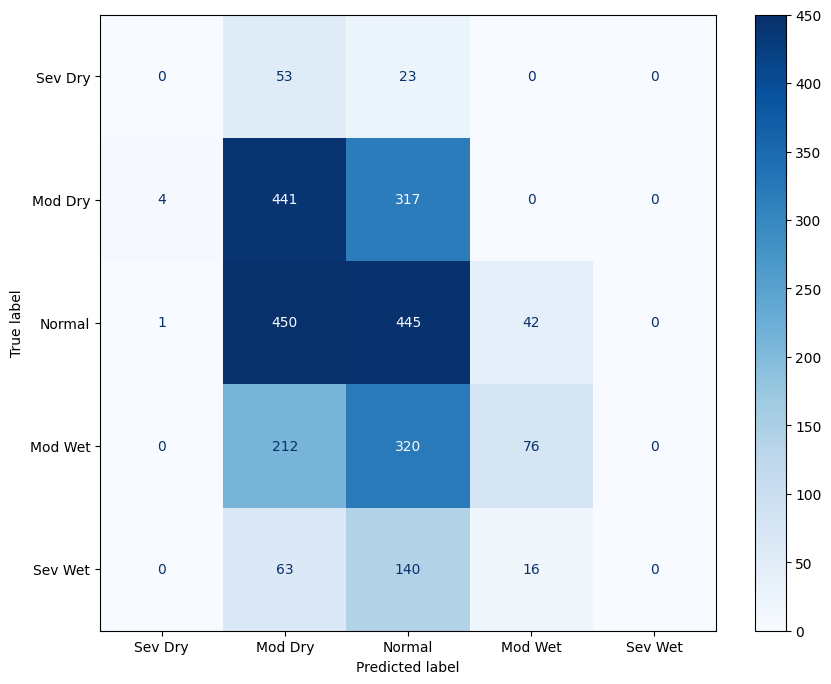

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ['Sev Dry', 'Mod Dry', 'Normal', 'Mod Wet', 'Sev Wet']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.show()

Using class weights

In [6]:
# Calculate weights based on how rare each category is
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(y_train), 
                                            y=y_train)
class_weights_dict = dict(enumerate(weights))
sample_weights = [class_weights_dict[label] for label in y_train]

In [7]:
model = XGBClassifier(
    n_estimators=50,           # Reduce from 100 to prevent long-term memorization
    max_depth=3,               # VERY IMPORTANT: Keep trees shallow (3-4 max)
    learning_rate=0.05,        # Slow down the learning
    min_child_weight=10,       # Prevents creating nodes for just 1 or 2 specific days
    subsample=0.8,             # Train on 80% of rows each time (adds randomness)
    colsample_bytree=0.8,      # Train on 80% of features each time
    gamma=1.0,                 # Minimum loss reduction to make a split
    objective='multi:softmax',
    num_class=5
)

model.fit(X_train, y_train, sample_weight=sample_weights)

# Get the importance scores
importances = model.feature_importances_

# Map them to your feature names
feature_info = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_info = feature_info.sort_values(by='Importance', ascending=False)

print(feature_info)

           Feature  Importance
9  target_category    0.344834
3             ssrd    0.128416
6        month_cos    0.125235
2              ssr    0.086397
4            swvl1    0.080603
5            swvl2    0.065454
7       tp_30d_sum    0.060458
0              sro    0.038840
8       tp_90d_sum    0.036216
1             ssro    0.033546


In [8]:
y_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Training Accuracy Obtained: {accuracy:.2%}")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"--- Model Results ---")
print(f"Test Accuracy Obtained: {accuracy:.2%}")
print(f"F1 Obtained: {f1:.2%}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Sev Dry', 'Mod Dry', 'Normal', 'Mod Wet', 'Sev Wet']))

Training Accuracy Obtained: 38.20%
--- Model Results ---
Test Accuracy Obtained: 29.50%
F1 Obtained: 27.33%

Classification Report:

              precision    recall  f1-score   support

     Sev Dry       0.14      0.78      0.24        76
     Mod Dry       0.40      0.44      0.42       762
      Normal       0.40      0.15      0.22       938
     Mod Wet       0.34      0.26      0.29       608
     Sev Wet       0.13      0.32      0.19       219

    accuracy                           0.30      2603
   macro avg       0.28      0.39      0.27      2603
weighted avg       0.35      0.30      0.29      2603



Confusion matrix for the 5 class classification at 30 day lead time using class weights

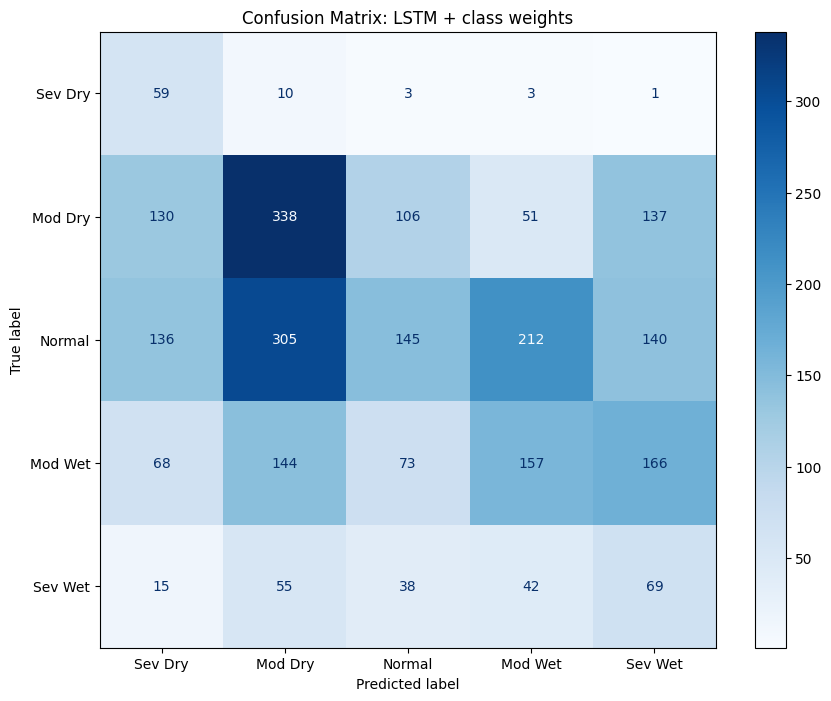

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it
labels = ['Sev Dry', 'Mod Dry', 'Normal', 'Mod Wet', 'Sev Wet']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix: LSTM + class weights')
plt.show()

Analysis

In [10]:
pd.crosstab(df['target_category'], df['target_next_month'], normalize='index')
# try using pearson correlation coefficient

target_next_month,0.0,1.0,2.0,3.0,4.0
target_category,,,,,
0,0.329365,0.317460,0.240079,0.093254,0.019841
1,0.068982,0.404906,0.323051,0.144766,0.058295
2,0.011133,0.356241,0.372725,0.183901,0.076001
3,0.000760,0.181922,0.422712,0.286365,0.108242
4,0.000000,0.133945,0.341284,0.341284,0.183486


In [11]:
# What happens if we just guess that next month is the same as this month?
persistence_preds = df['target_category'] 
persistence_acc = (persistence_preds == df['target_next_month']).mean()
print(f"Persistence Baseline: {persistence_acc:.2%}")

Persistence Baseline: 34.79%


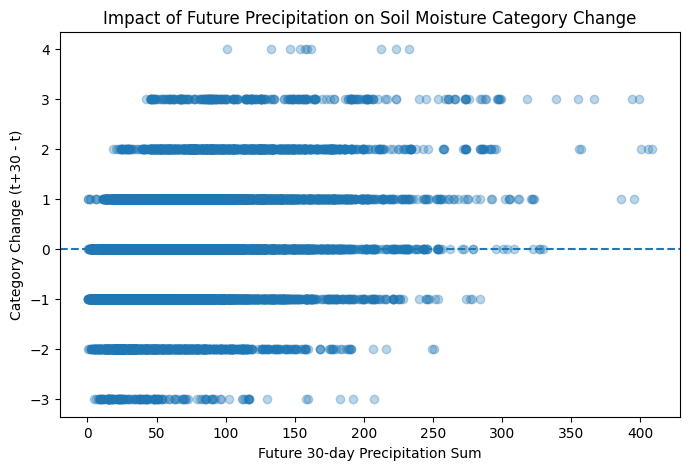

In [12]:
df['category_change'] = df['target_next_month'] - df['target_category']
df['tp_future_30d'] = df['tp'].rolling(window=30).sum().shift(-30)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['tp_future_30d'], df['category_change'], alpha=0.3)

plt.xlabel('Future 30-day Precipitation Sum')
plt.ylabel('Category Change (t+30 - t)')
plt.title('Impact of Future Precipitation on Soil Moisture Category Change')

plt.axhline(0, linestyle='--')  # no change line

plt.show()

The scatter plot shows a clear positive relationship between accumulated future precipitation and soil moisture category change. Higher precipitation totals are generally associated with positive category shifts (wetting), while low precipitation is linked to negative shifts (drying). However, there is substantial spread within each category change, indicating that precipitation alone does not fully determine the outcome and that variability remains high

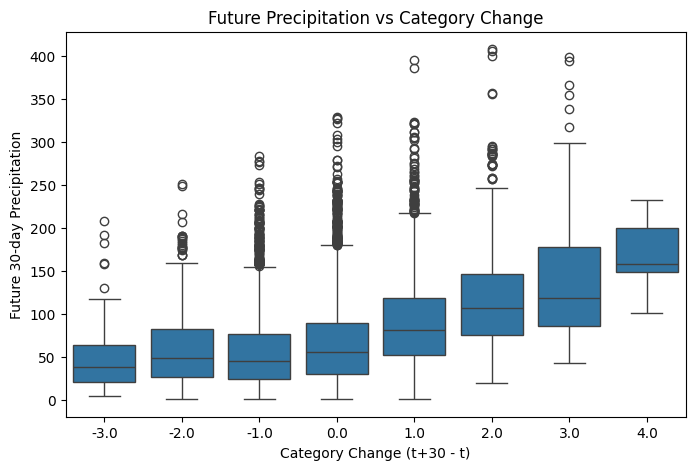

In [13]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['category_change'], y=df['tp_future_30d'])

plt.xlabel('Category Change (t+30 - t)')
plt.ylabel('Future 30-day Precipitation')
plt.title('Future Precipitation vs Category Change')

plt.show()

The boxplot reveals a clear monotonic increase in future precipitation with increasing category change. Median precipitation rises steadily from strong drying events (negative category changes) to strong wetting events (positive changes). This demonstrates that soil moisture transitions are strongly controlled by precipitation accumulated during the forecast period

#### 3 classes

30 day lead time

In [14]:
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear

# Ensure your time column is datetime and extract the month
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
# This helps the model understand that Dec and Jan are neighbors
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Calculate Mean and Std Dev per month (and per pixel/station if applicable)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()

# Merge stats back to original dataframe
df = df.merge(stats, on='month')

# Calculate Z-score
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# Create Buckets
bins = [-float('inf'), -0.5, 0.5, float('inf')]
labels = ['Dry', 'Normal', 'Wet']
labels = [0, 1, 2]
df['target_category'] = pd.cut(df['z_score'], bins=bins, labels=labels).astype(int)

df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90, center=False).sum()
# df['pev_30d_sum'] = df['pev'].rolling(window=30, center=False).sum()
df["target_next_month"] = df["target_category"].shift(-30)
df = df.dropna()
features = ['ssrd', 'pev', 'day_of_year', 'swvl2', 'tp_30d_sum']
features = ['tp', 'pev', 'e', 'evabs', 'evavt', 'ro', 'sro', 'ssro', 'smlt', 'slhf',
       'ssr', 'ssrd', 'str', 'strd', 't2m', 'd2m', 'skt', 'stl1', 'stl2', 'sd',
       'swvl1', 'swvl2', 'swvl3', 'swvl4', 'day_of_year', 'month_sin', 'month_cos', 'tp_30d_sum', 'tp_90d_sum', 'target_category']
X = df[features]
y = df['target_next_month']

# TRAIN-TEST SPLIT (80/20)
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Calculate weights based on how rare each category is
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(y_train), 
                                            y=y_train)
class_weights_dict = dict(enumerate(weights))
sample_weights = [class_weights_dict[label] for label in y_train]

model = XGBClassifier(
    n_estimators=50,           # Reduce from 100 to prevent long-term memorization
    max_depth=3,               # VERY IMPORTANT: Keep trees shallow (3-4 max)
    learning_rate=0.05,        # Slow down the learning
    min_child_weight=10,       # Prevents creating nodes for just 1 or 2 specific days
    subsample=0.8,             # Train on 80% of rows each time (adds randomness)
    colsample_bytree=0.8,      # Train on 80% of features each time
    gamma=1.0,                 # Minimum loss reduction to make a split
    objective='multi:softmax',
    num_class=5
)

model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Training Accuracy Obtained: {accuracy:.2%}")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Model Results ---")
print(f"Test Accuracy Obtained: {accuracy:.2%}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Dry', 'Normal', 'Wet']))

Training Accuracy Obtained: 51.88%
--- Model Results ---
Test Accuracy Obtained: 40.27%

Classification Report:

              precision    recall  f1-score   support

         Dry       0.38      0.59      0.46       838
      Normal       0.39      0.21      0.27       938
         Wet       0.45      0.43      0.44       824

    accuracy                           0.40      2600
   macro avg       0.41      0.41      0.39      2600
weighted avg       0.40      0.40      0.39      2600



Confusion matrix at 30 day lead time

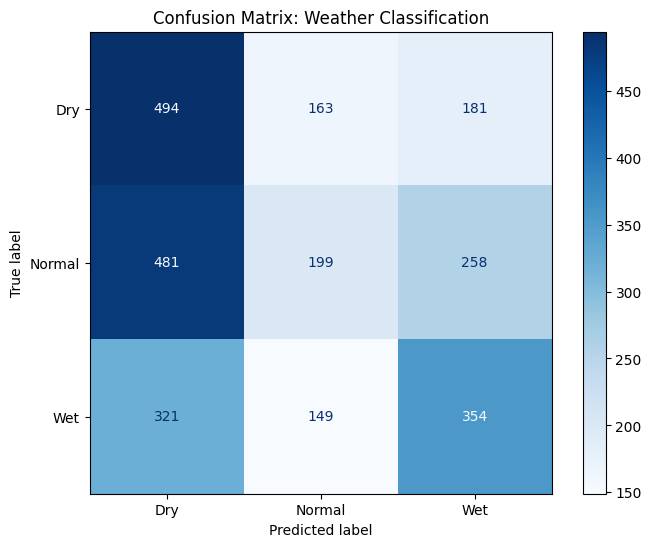

In [15]:
cm = confusion_matrix(y_test, y_pred)

labels = ['Dry', 'Normal', 'Wet']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix: Weather Classification')
plt.show()

#### Parameter tuning for XGBoost

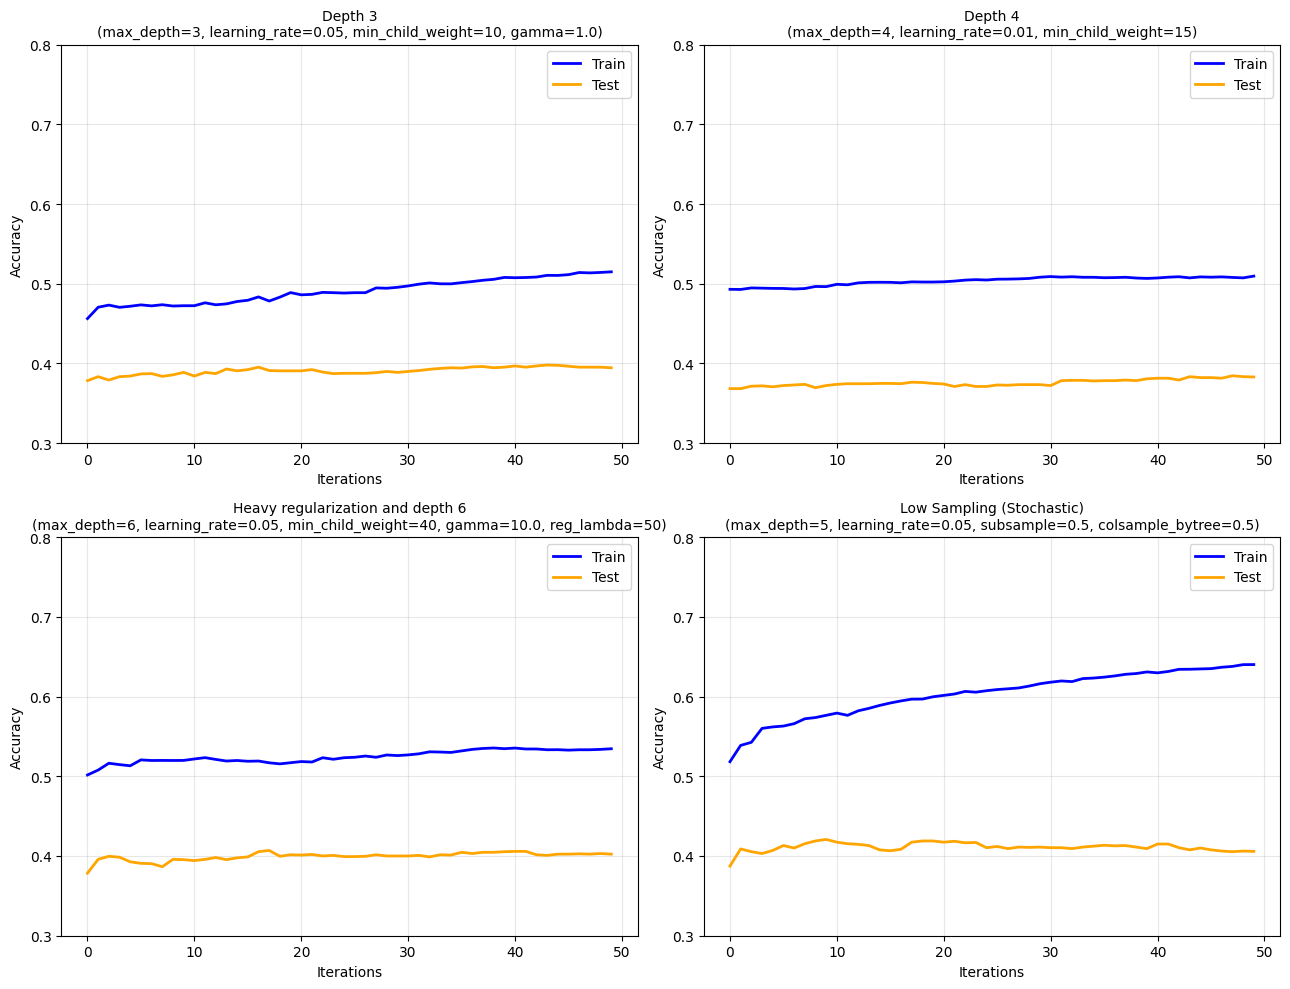

In [16]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=50,           # Reduce from 100 to prevent long-term memorization
    max_depth=3,               # VERY IMPORTANT: Keep trees shallow (3-4 max)
    learning_rate=0.05,        # Slow down the learning
    min_child_weight=10,       # Prevents creating nodes for just 1 or 2 specific days
    subsample=0.8,             # Train on 80% of rows each time (adds randomness)
    colsample_bytree=0.8,      # Train on 80% of features each time
    gamma=1.0,                 # Minimum loss reduction to make a split
    objective='multi:softmax',
    num_class=5
)

# Define 4 different configurations to test
configs = [
    {
        "name": "Depth 3",
        "params": {"max_depth": 3, "learning_rate": 0.05, "min_child_weight": 10, "gamma": 1.0}
    },
    {
        "name": "Depth 4",
        "params": {"max_depth": 4, "learning_rate": 0.01, "min_child_weight": 15}
    },
    {
        "name": "Heavy regularization and depth 6",
        "params": {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 40, "gamma": 10.0, "reg_lambda": 50}
    },
    {
        "name": "Low Sampling (Stochastic)",
        "params": {"max_depth": 5, "learning_rate": 0.05, "subsample": 0.5, "colsample_bytree": 0.5}
    }    
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, config in enumerate(configs):
    # Initialize model with basic settings + specific config params
    model = XGBClassifier(
        n_estimators=50,
        objective='multi:softmax',
        num_class=5,
        eval_metric="merror",
        random_state=42,
        **config["params"]
    )

    # Fit the model
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
    )

    # Retrieve Results
    results = model.evals_result()
    train_acc = [1 - x for x in results['validation_0']['merror']]
    test_acc = [1 - x for x in results['validation_1']['merror']]

    # Plot in the subplot
    ax = axes[i]
    ax.plot(train_acc, label='Train', color='blue', linewidth=2)
    ax.plot(test_acc, label='Test', color='orange', linewidth=2)
    
    # Title showing the core change
    param_str = ", ".join([f"{k}={v}" for k, v in config["params"].items()])
    ax.set_title(f"{config['name']}\n({param_str})", fontsize=10)
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.3, 0.8) # Keeps the scale consistent for comparison
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()